In [ ]:
import seaborn as sns
import numpy as np
import ast, re 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
PATH_PREFIX = os.environ.get('MEDAL_DATA_DIR', os.path.join(os.path.expanduser('~'), 'drd_data'))

_NATURE_RC = {
    "font.family":         "sans-serif",
    "font.sans-serif":     ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":           15,
    "axes.labelsize":      13,
    "axes.titlesize":      15,
    "axes.labelpad":       9,
    "axes.linewidth":      0.5,
    "xtick.labelsize":     12,
    "ytick.labelsize":     12,
    "xtick.major.size":    2,
    "ytick.major.size":    2,
    "xtick.major.width":   0.5,
    "ytick.major.width":   0.5,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
    "legend.title_fontsize" : 13,
    "legend.fontsize":     12,
}

_CAT_ORDER = ["None", "ReLU", "SELU"]
_TEACHERS  = ["TSNE", "PCA", "UMAP"]


def make_activation_figs(
    datasets,
    mode: str = "distill",
    bar_width: float = 0.16,
    figsize_per_row: tuple = (5.5, 1.8),
    save_path = None,
    dpi: int = 300,
):
    if mode == "distill":
        y_col, y_label, use_log = "distill_loss", "Distillation loss", True
    elif mode == "recon":
        y_col, y_label, use_log = "recon_loss", "Reconstruction loss", False
    else:
        raise ValueError(f"mode must be 'distill' or 'recon'")

    TEACHER_COLORS = {
        "TSNE": "#E64B35", "PCA": "#4DBBD5",
        "UMAP": "#00A087", 
    }
    TEACHER_LABELS = {
        "TSNE": "t-SNE", "PCA": "PCA",
        "UMAP": "UMAP", 
    }

    # collapse ReLU + SELU = "Nonlinear", None = "Linear"
    def binarize(col):
        return col.map(lambda x: "Linear" if x == "None" else "Nonlinear")

    BINARY_ORDER   = ["Linear", "Nonlinear"]
    PANEL_CONFIGS = [
        ("Bottleneck activation", "bottleneck_activation", None,                   None),
        ("Hidden activation",     "activation",            "bottleneck_activation", "None"),
    ]

    n_rows     = len(datasets)
    n_teachers = len(_TEACHERS)
    n_groups   = len(BINARY_ORDER)
    offsets    = np.linspace(
        -(n_teachers - 1) / 2 * bar_width,
         (n_teachers - 1) / 2 * bar_width,
        n_teachers,
    )
    group_centers = np.arange(n_groups)

    fig_w, fig_h_per = figsize_per_row

    with plt.rc_context(_NATURE_RC):
        fig, axes = plt.subplots(
            n_rows, 2,
            figsize=(fig_w, fig_h_per * n_rows),
            squeeze=False,
            sharey="row",
        )
        fig.subplots_adjust(
            hspace=0.42, wspace=0.08,
            left=0.15, right=0.98,
            top=0.91, bottom=0.12,
        )
        for row_idx, (df_raw, dname) in enumerate(datasets):
            df = prep(df_raw).copy()
            df = df.reset_index().rename(columns={
                'config/activation':'activation',
                'config/bottleneck_activation':'bottleneck_activation'})
            df['bottleneck_activation'] = df['bottleneck_activation'].fillna('None').replace({'nan':'None'})
            df['activation'] = df['activation'].fillna('None').replace({'nan':'None'})
            

            for col_idx, (panel_title, focal_col, filter_col, filter_val) in enumerate(PANEL_CONFIGS):
                ax = axes[row_idx][col_idx]
                df["_focal"] = binarize(df[focal_col])

                for t_idx, teacher in enumerate(_TEACHERS):
                    df_t = df[df["teacher"] == teacher]
                    color = TEACHER_COLORS[teacher]

                    if filter_col is not None:
                        df_t = df_t[df_t[filter_col] == filter_val]

                    means, sems = [], []
                    for grp in BINARY_ORDER:
                        vals = df_t.loc[df_t["_focal"] == grp, y_col].dropna().values
                        if len(vals) == 0:
                            means.append(np.nan)
                            sems.append(0)
                            continue
                        means.append(vals.mean())
                        sems.append(vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)
                        
                    xs = group_centers + offsets[t_idx]
                    ax.bar(
                        xs, means,
                        width=bar_width * 0.88,
                        color=color, alpha=0.88,
                        label=TEACHER_LABELS[teacher],
                        zorder=3,
                    ) 
                    
                    ax.errorbar(xs, means, yerr=sems, fmt="none", ecolor="black", elinewidth=0.6, capsize=2, capthick=0.6, zorder=4)

                ax.set_xticks(group_centers)
                ax.set_xticklabels(BINARY_ORDER)
                ax.set_xlim(-0.5, n_groups - 0.5)

                if use_log:
                    ax.set_yscale("log")

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.spines["left"].set_linewidth(0.5)
                ax.spines["bottom"].set_linewidth(0.5)
                ax.tick_params(length=2.5, width=0.5, pad=2)
                ax.yaxis.grid(True, linestyle=":", linewidth=0.4,
                              color="#bbbbbb", zorder=0)
                ax.set_axisbelow(True)
                if row_idx == 0:
                    ax.set_title(panel_title, fontweight="bold", pad=5)

                if row_idx == n_rows - 1:
                    ax.set_xlabel(panel_title)
                if col_idx == 0:
                    ax.set_ylabel(y_label)
                    ax.annotate(
                        dname,
                        xy=(-0.35, 0.5), xycoords="axes fraction",
                        fontsize=_NATURE_RC["axes.labelsize"],
                        fontweight="bold",
                        ha="right", va="center",
                        rotation=90, annotation_clip=False,
                    )

        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            title="Teacher", frameon=False,
            loc="upper center",
            bbox_to_anchor=(1.3, 0.5),
            ncol=n_teachers,
            handlelength=1.2, handletextpad=0.4, columnspacing=0.9,
        )

        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

        plt.show()

def flatten_cols(df):
    """('distill_loss','mean') -> 'distill_loss_mean'."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = ['_'.join([str(c) for c in tup if c!='']).strip('_') for tup in df.columns]

    return df.reset_index().rename(columns={
        # 'config/activation':'activation',
        # 'config/bottleneck_activation':'bottleneck_activation',
        'config/hidden_dims':'hidden_dims',
        'distill_loss_mean':'distill_loss',
        'recon_loss_mean':'recon_loss',
        'time_total_s_mean':'time_total_s',
    })

def infer_arch_cols(df):
    def _parse(s):
        """Handle both '[256, 256, 256]' list strings and '256x3' compact strings."""
        s = str(s).strip()
        # compact format produced by run_depth_analysis.py: "256x3"
        m = re.fullmatch(r'(\d+)x(\d+)', s)
        if m:
            w, l = int(m.group(1)), int(m.group(2))
            return l, w, 'x'.join([str(w)] * l)   # depth, width, sig
        try:
            xs = ast.literal_eval(s)
            return len(xs), xs[0], '×'.join(map(str, xs))
        except Exception:
            nums = list(map(int, re.findall(r'\d+', s)))
            return len(nums), nums[0] if nums else 0, str(s)

    df = df.copy()
    parsed = df['hidden_dims'].map(_parse)
    df['arch_depth'] = parsed.map(lambda t: t[0])
    df['arch_width'] = parsed.map(lambda t: t[1])
    df['arch_sig']   = parsed.map(lambda t: t[2])
    return df

def prep(df):
    df = flatten_cols(df)
    # keep only rows with the means we need
    for c in ['teacher','hidden_dims','distill_loss','recon_loss']:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
    df = infer_arch_cols(df)

    return df

def make_depth_figs(
    datasets,                    
    set_y_distill_scale: bool = True,
    figsize_per_row: tuple = (5.5, 1.8),
    save_path = None,
    dpi: int = 300,
):
    TEACHER_COLORS = {
        "TSNE": "#E64B35", "PCA": "#4DBBD5",
        "UMAP": "#00A087", "SpectralEmbedding": "#3C5488",
    }
    TEACHER_LABELS = {
        "TSNE": "t-SNE", "PCA": "PCA",
        "UMAP": "UMAP", "SpectralEmbedding": "Spectral",
    }

    n_rows = len(datasets)
    fig_w, fig_h_per = figsize_per_row

    with plt.rc_context(_NATURE_RC):
        fig, axes = plt.subplots(
            n_rows, 2,
            figsize=(fig_w, fig_h_per * n_rows),
            squeeze=False,
        )
        fig.subplots_adjust(
            hspace=0.42, wspace=0.2,
            left=0.15, right=0.85,
            top=0.91, bottom=0.12,
        )

        for row_idx, (df_raw, dname) in enumerate(datasets):
            df     = prep(df_raw).copy()
            print(df["arch_depth"].unique())
            depths = sorted(df["arch_depth"].unique())

            for col_idx, (y_col, y_label, use_log) in enumerate([
                ("distill_loss", "Distillation loss", set_y_distill_scale),
                ("recon_loss",   "Reconstruction loss", False),
            ]):
                ax = axes[row_idx][col_idx]

                for teacher, color in TEACHER_COLORS.items():
                    df_t = df[df["teacher"] == teacher]
                    if df_t.empty:
                        continue

                    xs, ys, lo_errs, hi_errs = [], [], [], []
                    for i, depth in enumerate(depths):
                        vals = df_t.loc[df_t["arch_depth"] == depth, y_col].dropna().values
                        if len(vals) == 0:
                            continue
                        mu = vals.mean()
                        if len(vals) > 1:
                            boots = np.array([
                                np.random.choice(vals, len(vals), replace=True).mean()
                                for _ in range(1000)
                            ])
                            ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
                        else:
                            ci_lo = ci_hi = mu
                        xs.append(i)
                        ys.append(mu)
                        lo_errs.append(mu - ci_lo)
                        hi_errs.append(ci_hi - mu)

                    ax.plot(
                        xs, ys,
                        color=color,
                        linewidth=0.9,
                        marker="o",
                        markersize=3,
                        markeredgewidth=0,
                        label=TEACHER_LABELS[teacher],
                        zorder=3,
                    )
                    ax.fill_between(
                        xs,
                        [y - e for y, e in zip(ys, lo_errs)],
                        [y + e for y, e in zip(ys, hi_errs)],
                        color=color,
                        alpha=0.12,
                        linewidth=0,
                        zorder=2,
                    )

                depth_to_width = df.groupby("arch_depth")["arch_width"].first().to_dict()
                ax.set_xticks(range(len(depths)))
                ax.set_xticklabels(
                    [f"{d}" for d in depths],
                    rotation=45, ha="right",
                )
                ax.set_xlim(-0.4, len(depths) - 0.6)

                if use_log:
                    ax.set_yscale("log")

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.spines["left"].set_linewidth(0.5)
                ax.spines["bottom"].set_linewidth(0.5)
                ax.tick_params(length=2.5, width=0.5, pad=2)
                ax.yaxis.grid(True, linestyle=":", linewidth=0.4,
                              color="#bbbbbb", zorder=0)
                ax.set_axisbelow(True)
                if row_idx == 0:
                    ax.set_title(
                        ["Distillation loss", "Reconstruction loss"][col_idx],
                        fontweight="bold", pad=5,
                    )
                if row_idx == n_rows - 1:
                    ax.set_xlabel("Architecture depth (# encoder hidden layers)")

                if col_idx == 0:
                    ax.set_ylabel(y_label)
                    ax.annotate(
                        dname,
                        xy=(-0.32, 0.5), xycoords="axes fraction",
                        fontsize=_NATURE_RC["axes.labelsize"],
                        fontweight="bold",
                        ha="right", va="center",
                        rotation=90, annotation_clip=False,
                    )

        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            title="Teacher", frameon=False,
            loc="center left",
            bbox_to_anchor=(0.86, 0.5),
            handlelength=1.2, handletextpad=0.4, labelspacing=0.5,
        )

        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

        plt.show()

def make_size_figs(
    datasets,                        
    order,                           
    set_y_distill_scale: bool = True,
    figsize_per_row: tuple = (5.5, 1.8),
    save_path=None,
    dpi: int = 300,
):
    TEACHER_COLORS = {
        "TSNE": "#E64B35", "PCA": "#4DBBD5",
        "UMAP": "#00A087", "SpectralEmbedding": "#3C5488",
    }
    TEACHER_LABELS = {
        "TSNE": "t-SNE", "PCA": "PCA",
        "UMAP": "UMAP", "SpectralEmbedding": "Spectral",
    }

    x_positions = {label: i for i, label in enumerate(order)}
    xs_numeric  = list(range(len(order)))

    n_rows = len(datasets)
    fig_w, fig_h_per = figsize_per_row

    with plt.rc_context(_NATURE_RC):
        fig, axes = plt.subplots(n_rows, 2,figsize=(fig_w, fig_h_per * n_rows),
            squeeze=False,
        )
        fig.subplots_adjust(hspace=0.42, wspace=0.2, left=0.15, right=0.85, top=0.91, bottom=0.12)

        for row_idx, (df_raw, dname) in enumerate(datasets):
            df = flatten_cols(df_raw).copy() 

            for col_idx, (y_col, y_label, use_log) in enumerate([
                ("distill_loss", "Distillation loss", set_y_distill_scale),
                ("recon_loss",   "Reconstruction loss", False),
            ]):
                ax = axes[row_idx][col_idx]

                for teacher, color in TEACHER_COLORS.items():
                    df_t = df[df["teacher"] == teacher]
                    if df_t.empty:
                        continue

                    xs_plot, ys, lo_errs, hi_errs = [], [], [], []
                    for arch_label in order:
                        vals = (
                            df_t.loc[df_t["hidden_dims"] == arch_label, y_col]
                            .dropna().values
                        )
                        if len(vals) == 0:
                            continue
                        mu = vals.mean()
                        if len(vals) > 1:
                            boots = np.array([
                                np.random.choice(vals, len(vals), replace=True).mean()
                                for _ in range(1000)
                            ])
                            ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
                        else:
                            ci_lo = ci_hi = mu
                        xs_plot.append(x_positions[arch_label])
                        ys.append(mu)
                        lo_errs.append(mu - ci_lo)
                        hi_errs.append(ci_hi - mu)

                    ax.plot(
                        xs_plot, ys,
                        color=color, linewidth=0.9,
                        marker="o", markersize=3, markeredgewidth=0,
                        label=TEACHER_LABELS[teacher], zorder=3,
                    )
                    ax.fill_between(
                        xs_plot,
                        [y - e for y, e in zip(ys, lo_errs)],
                        [y + e for y, e in zip(ys, hi_errs)],
                        color=color, alpha=0.12, linewidth=0, zorder=2,
                    )
                ax.set_xticks(xs_numeric)
                ax.set_xlim(-0.4, len(order) - 0.6)

                if use_log:
                    ax.set_yscale("log")

                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                ax.spines["left"].set_linewidth(0.5)
                ax.spines["bottom"].set_linewidth(0.5)
                ax.tick_params(length=2.5, width=0.5, pad=2)
                ax.yaxis.grid(True, linestyle=":", linewidth=0.4,
                              color="#bbbbbb", zorder=0)
                ax.set_axisbelow(True)
                if row_idx == 0:
                    ax.set_title(
                        ["Distillation loss", "Reconstruction loss"][col_idx],
                        fontweight="bold", pad=5,
                    )
                if row_idx == n_rows - 1:
                    ax.set_xticklabels(order, rotation=45, ha="right")
                    ax.set_xlabel("Architecture size (hidden layer widths)")
                else:
                    ax.set_xticklabels([]) 

                if col_idx == 0:
                    ax.set_ylabel(y_label)
                    ax.annotate(
                        dname,
                        xy=(-0.32, 0.5), xycoords="axes fraction",
                        fontsize=_NATURE_RC["axes.labelsize"],
                        fontweight="bold",
                        ha="right", va="center",
                        rotation=90, annotation_clip=False,
                    )

        # shared legend
        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(
            handles, labels,
            title="Teacher", frameon=False,
            loc="center left",
            bbox_to_anchor=(0.86, 0.5),
            handlelength=1.2, handletextpad=0.4, labelspacing=0.5,
        )

        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

        plt.show()

### Lambda_d

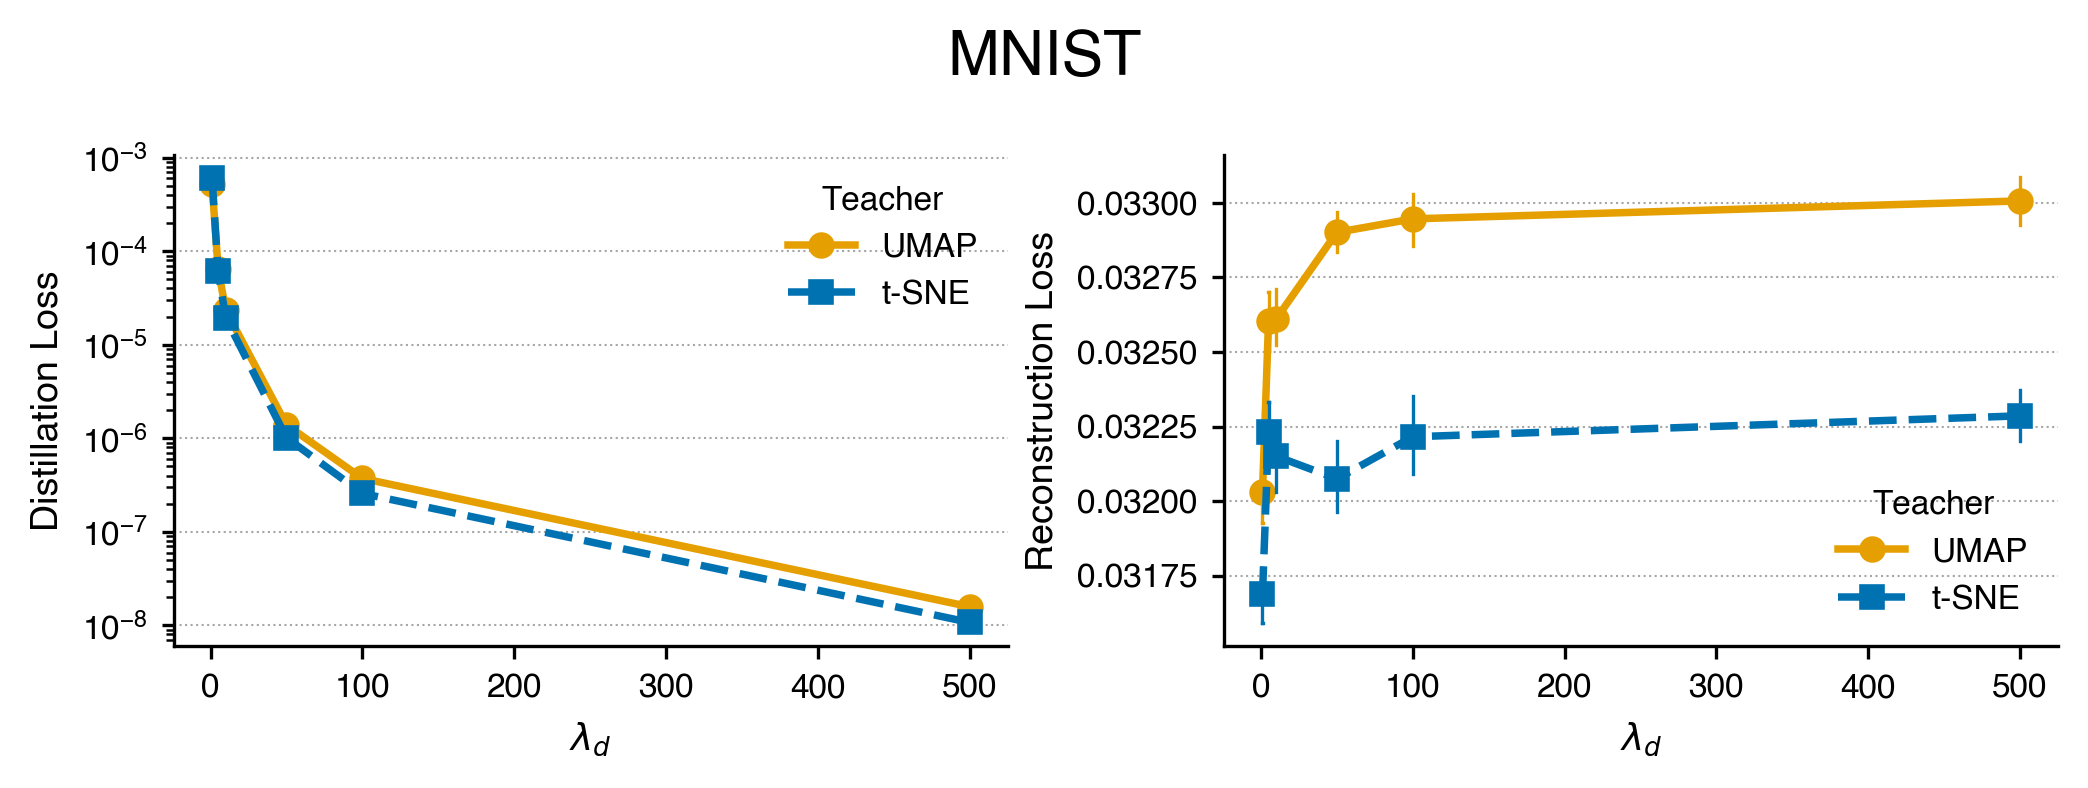

In [149]:
analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'mnist_lambda_d_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) / 'mnist_lambda_d_analysis_tsne.csv')
analysis_tsne['teacher'] = "t-SNE"
analysis = pd.concat([analysis_umap, analysis_tsne], ignore_index=True)

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":        8,
    "axes.titlesize":   9,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "legend.fontsize":  8,
    "lines.linewidth":  1,
    "lines.markersize": 10,
    "axes.linewidth":   0.8,
    "xtick.major.width":0.8,
    "ytick.major.width":0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "legend.frameon":   False,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

PALETTE = {"t-SNE": "#0072B2", "UMAP": "#E69F00"}   

fig, axes = plt.subplots(1, 2, figsize=(7, 2.6))   

sns.pointplot(
    data=analysis,x="lambda_d",y="distill_loss", hue="teacher", palette=PALETTE, native_scale=True,
    dodge=False, markers=["o", "s"], linestyles=["-", "--"],  capsize=0.05,  err_kws={"linewidth": 0.8},
    ax=axes[0], markersize = 5)

sns.pointplot(
    data=analysis,x="lambda_d",y="recon_loss", hue="teacher", palette=PALETTE, native_scale=True,
    dodge=False, markers=["o", "s"],  linestyles=["-", "--"], capsize=0.05, err_kws={"linewidth": 0.8},
    ax=axes[1],markersize = 5
)

axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
axes[0].set_xlabel(r"$\lambda_d$")
axes[0].set_ylabel("Distillation Loss")
axes[0].legend(title="Teacher", title_fontsize=8, loc="best")

axes[1].set_xlabel(r"$\lambda_d$")
axes[1].set_ylabel("Reconstruction Loss")
axes[1].legend(title="Teacher", title_fontsize=8, loc="best")
for ax in axes:
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.7)
    ax.set_axisbelow(True)
plt.suptitle("MNIST", fontsize=15)
plt.tight_layout()
plt.show()

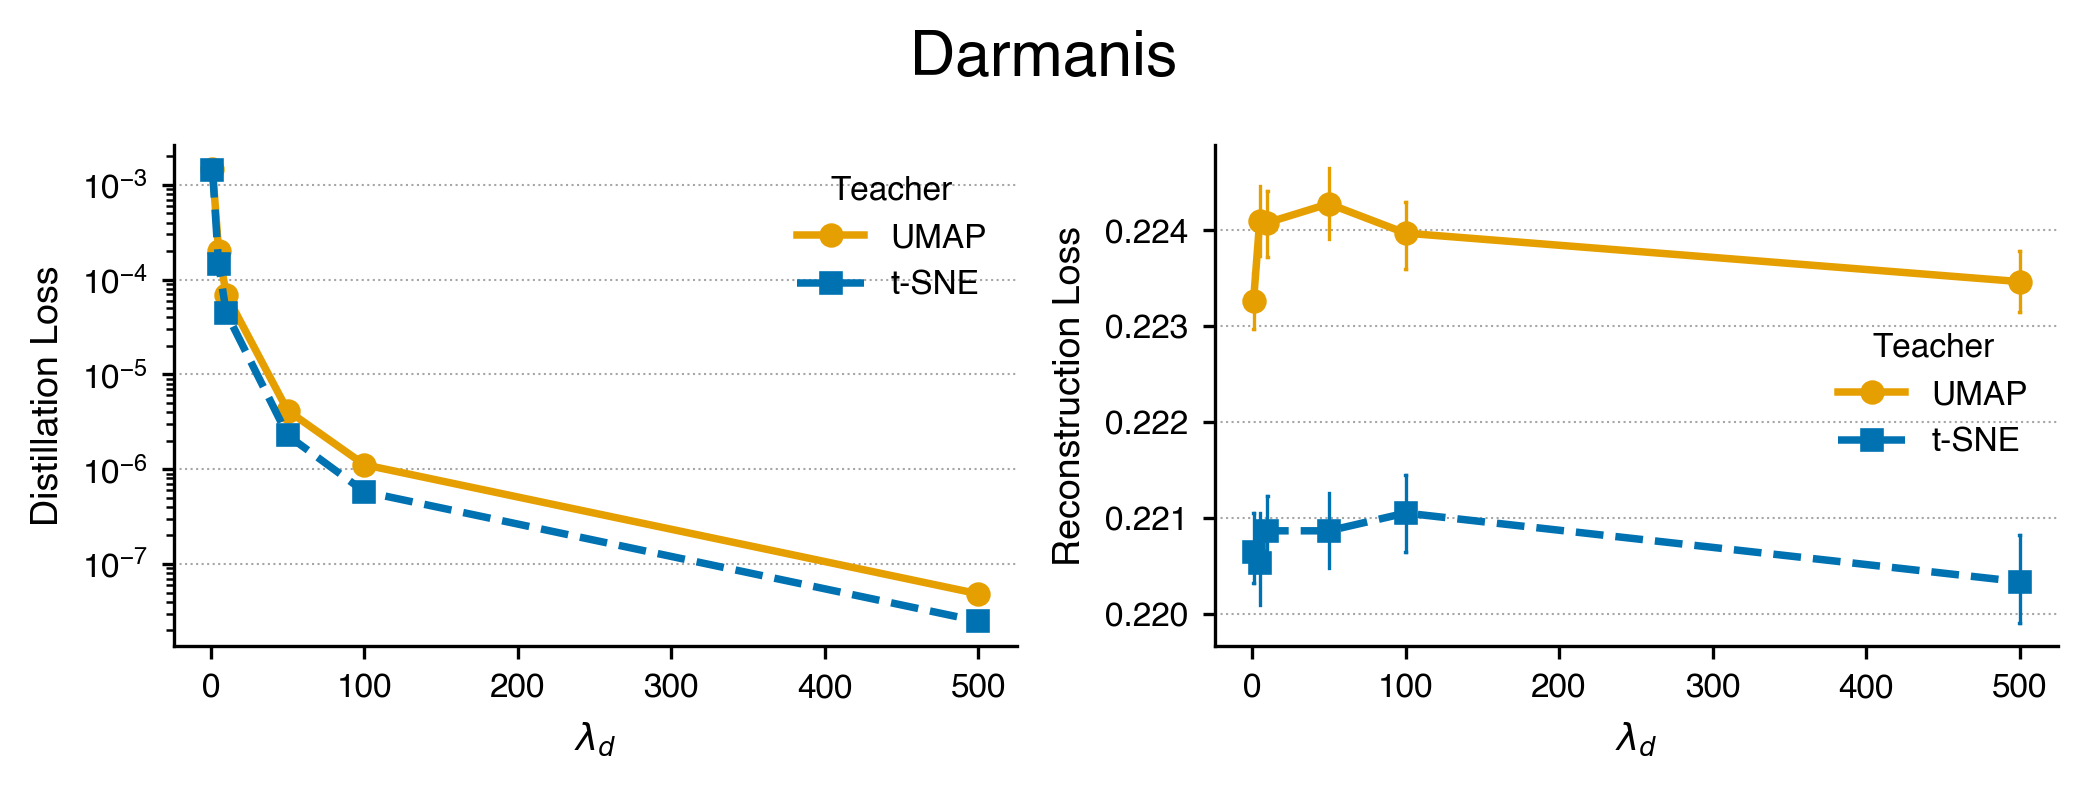

In [151]:
analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'darmanis_lambda_d_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) /'darmanis_lambda_d_analysis_tsne.csv')
analysis_tsne['teacher'] = "t-SNE"
analysis = pd.concat([analysis_umap, analysis_tsne], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(7, 2.6))   

sns.pointplot(
    data=analysis,x="lambda_d",y="distill_loss", hue="teacher", palette=PALETTE, native_scale=True,
    dodge=False, markers=["o", "s"],  linestyles=["-", "--"],  capsize=0.05,  err_kws={"linewidth": 0.8},
    ax=axes[0],)

sns.pointplot(
    data=analysis,x="lambda_d",y="recon_loss", hue="teacher", palette=PALETTE, native_scale=True,
    dodge=False, markers=["o", "s"],  linestyles=["-", "--"],   
    capsize=0.05, err_kws={"linewidth": 0.8},
    ax=axes[1],
)
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))

axes[0].set_xlabel(r"$\lambda_d$")
axes[0].set_ylabel("Distillation Loss")
axes[0].legend(title="Teacher", title_fontsize=8, loc="best")

axes[1].set_xlabel(r"$\lambda_d$")
axes[1].set_ylabel("Reconstruction Loss")
axes[1].legend(title="Teacher", title_fontsize=8, loc="best")
for ax in axes:
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.7)
    ax.set_axisbelow(True)
plt.suptitle("Darmanis", fontsize=15)
plt.tight_layout()
plt.show()

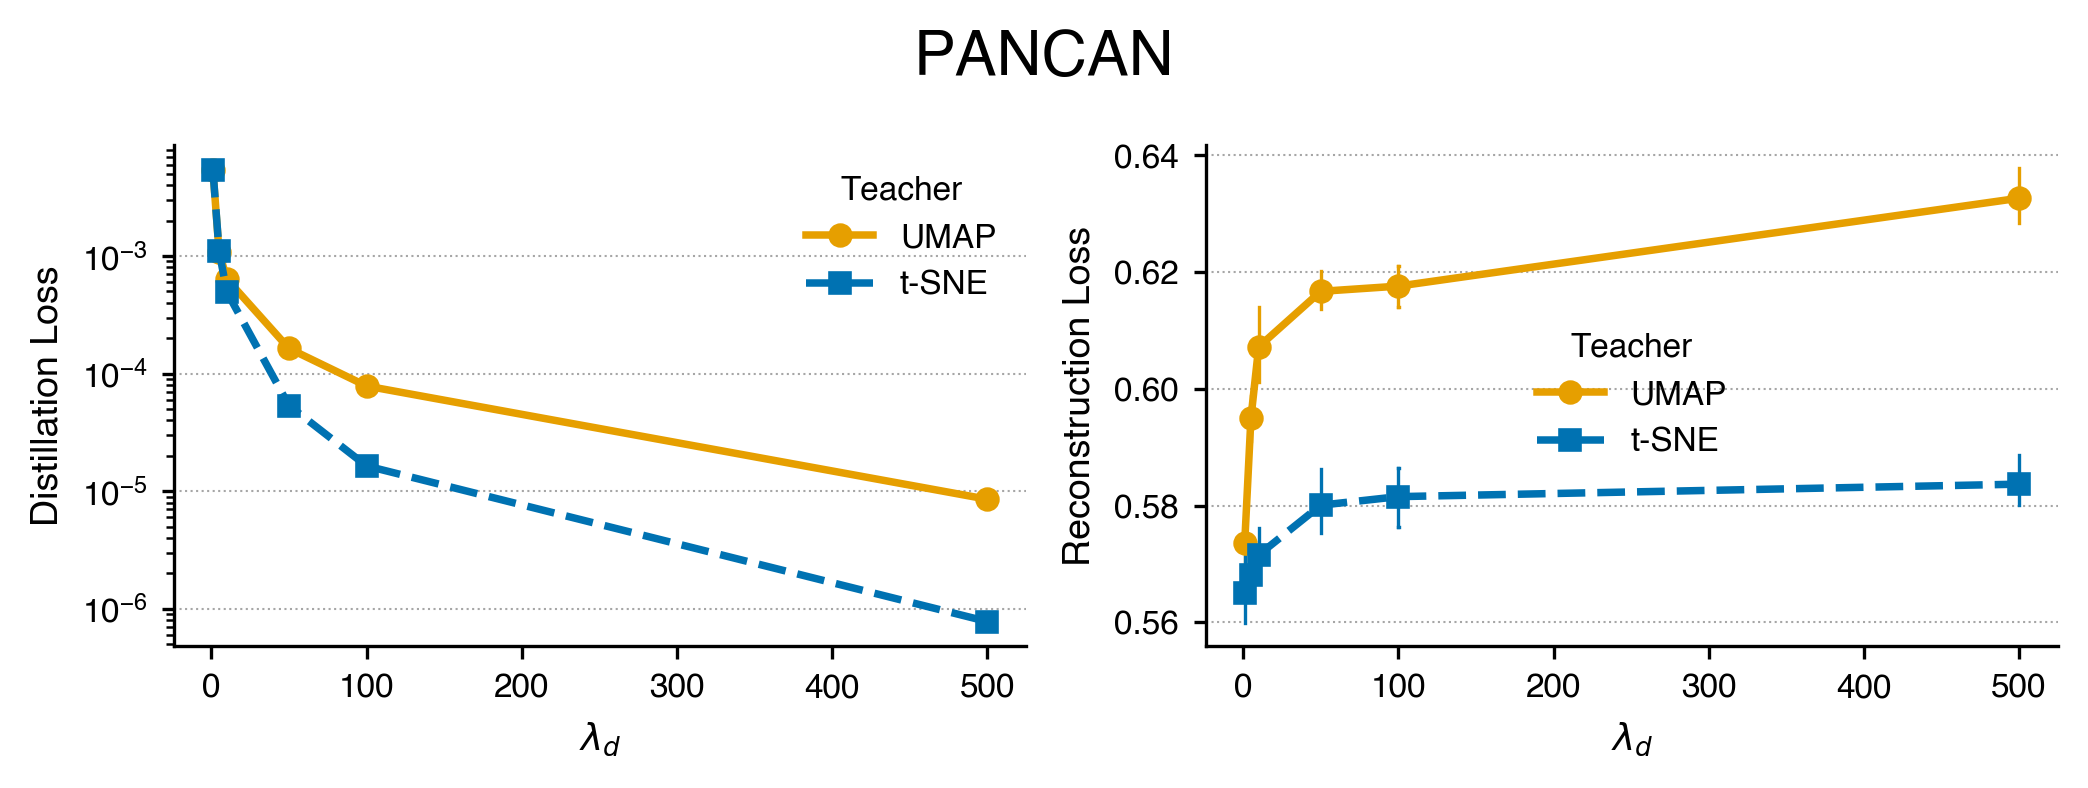

In [150]:
analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'gene_cancer_lambda_d_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) /'gene_cancer_lambda_d_analysis_tsne.csv')
analysis_tsne['teacher'] = "t-SNE"
analysis = pd.concat([analysis_umap, analysis_tsne], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(7, 2.6)) 
sns.pointplot(
    data=analysis,x="lambda_d",y="distill_loss", hue="teacher", palette=PALETTE, native_scale=True,
    dodge=False, markers=["o", "s"], linestyles=["-", "--"],  capsize=0.05, 
    err_kws={"linewidth": 0.8}, ax=axes[0],)

sns.pointplot(
    data=analysis,x="lambda_d",y="recon_loss", hue="teacher", palette=PALETTE, native_scale=True,
    dodge=False,
    markers=["o", "s"],          
    linestyles=["-", "--"],      
    capsize=0.05,                
    err_kws={"linewidth": 0.8},
    ax=axes[1],
)

axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
axes[0].set_xlabel(r"$\lambda_d$")
axes[0].set_ylabel("Distillation Loss")
axes[0].legend(title="Teacher", title_fontsize=8, loc="best")

axes[1].set_xlabel(r"$\lambda_d$")
axes[1].set_ylabel("Reconstruction Loss")
axes[1].legend(title="Teacher", title_fontsize=8, loc="best")
for ax in axes:
    ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="gray", alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle("PANCAN", fontsize=15)
plt.tight_layout()
plt.show()

### Activation

In [31]:
analysis_umap = pd.read_csv(Path(PATH_PREFIX) /'activation_gene_cancer_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_pca = pd.read_csv(Path(PATH_PREFIX) /'activation_gene_cancer_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) /'activation_gene_cancer_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_pancan = pd.concat([analysis_tsne, analysis_pca, analysis_umap], ignore_index=True)
analysis_pancan.fillna('None', inplace=True)

analysis_pca = pd.read_csv(Path(PATH_PREFIX) / 'activation_mnist_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'activation_mnist_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) /'activation_mnist_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_mnist = pd.concat([analysis_pca, analysis_umap, analysis_tsne], ignore_index=True)
analysis_mnist.fillna('None', inplace=True)

analysis_pca = pd.read_csv(Path(PATH_PREFIX) /'activation_darmanis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_umap = pd.read_csv(Path(PATH_PREFIX) /'activation_darmanis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) / 'activation_darmanis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_darmanis = pd.concat([analysis_pca, analysis_umap, analysis_tsne], ignore_index=True)
analysis_darmanis.fillna('None', inplace=True)

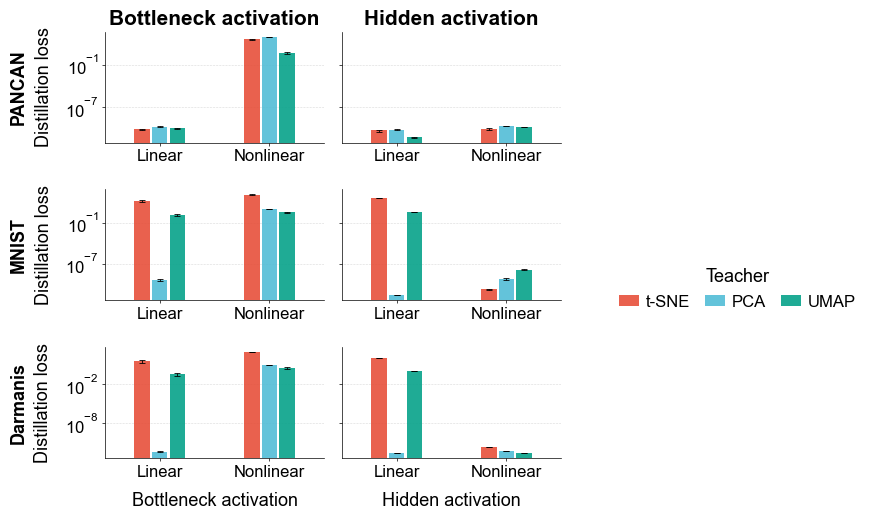

In [33]:
make_activation_figs(
    [
        (analysis_pancan,   "PANCAN"),
        (analysis_mnist,    "MNIST"),
        (analysis_darmanis,    "Darmanis"),
    ],
    mode="distill"
)

### Depth

[2 3 4 6 8]
[2 3 4 6 8]
[2 3 4 6 8]


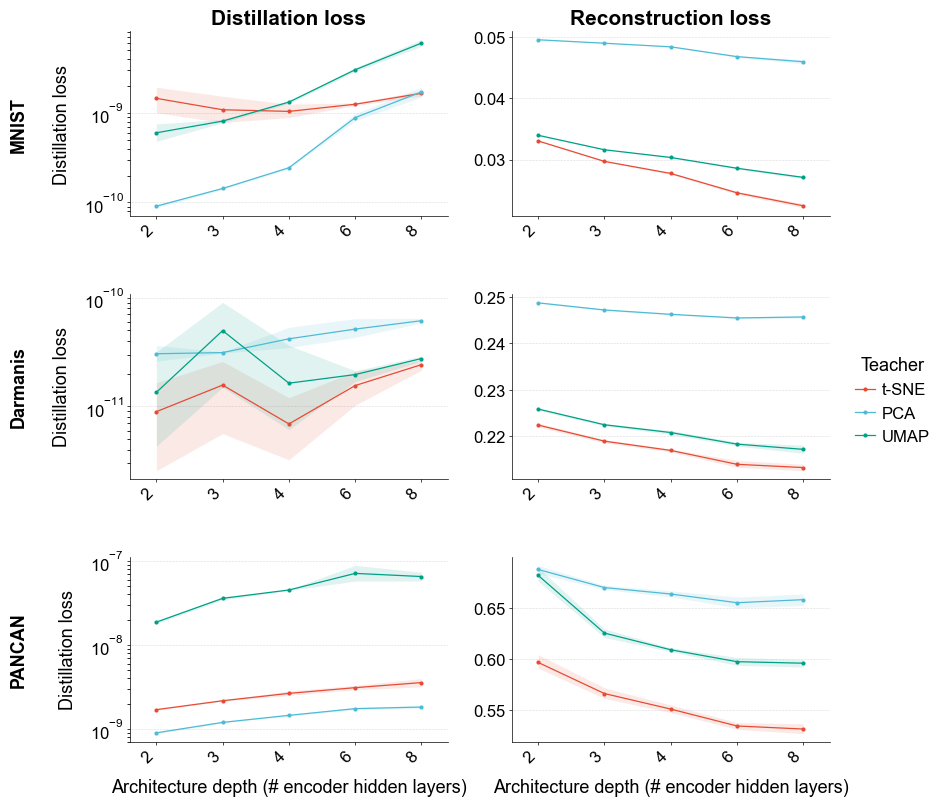

In [23]:
analysis_umap = pd.read_csv(Path(PATH_PREFIX) /'mnist_depth_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) /'mnist_depth_analysis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_pca = pd.read_csv(Path(PATH_PREFIX) / 'mnist_depth_analysis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_mnist = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)

analysis_pca = pd.read_csv(Path(PATH_PREFIX) /'darmanis_depth_analysis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) /'darmanis_depth_analysis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_umap = pd.read_csv(Path(PATH_PREFIX) /'darmanis_depth_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_darmanis = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)

analysis_pca = pd.read_csv(Path(PATH_PREFIX) /'gene_cancer_depth_analysis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) / 'gene_cancer_depth_analysis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'gene_cancer_depth_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_pancan = pd.concat([analysis_pca, analysis_tsne, analysis_umap], ignore_index=True)
    
make_depth_figs([(analysis_mnist, "MNIST"), (analysis_darmanis, "Darmanis"), (analysis_pancan, "PANCAN")], set_y_distill_scale=True, figsize_per_row = (10, 3))

### Size

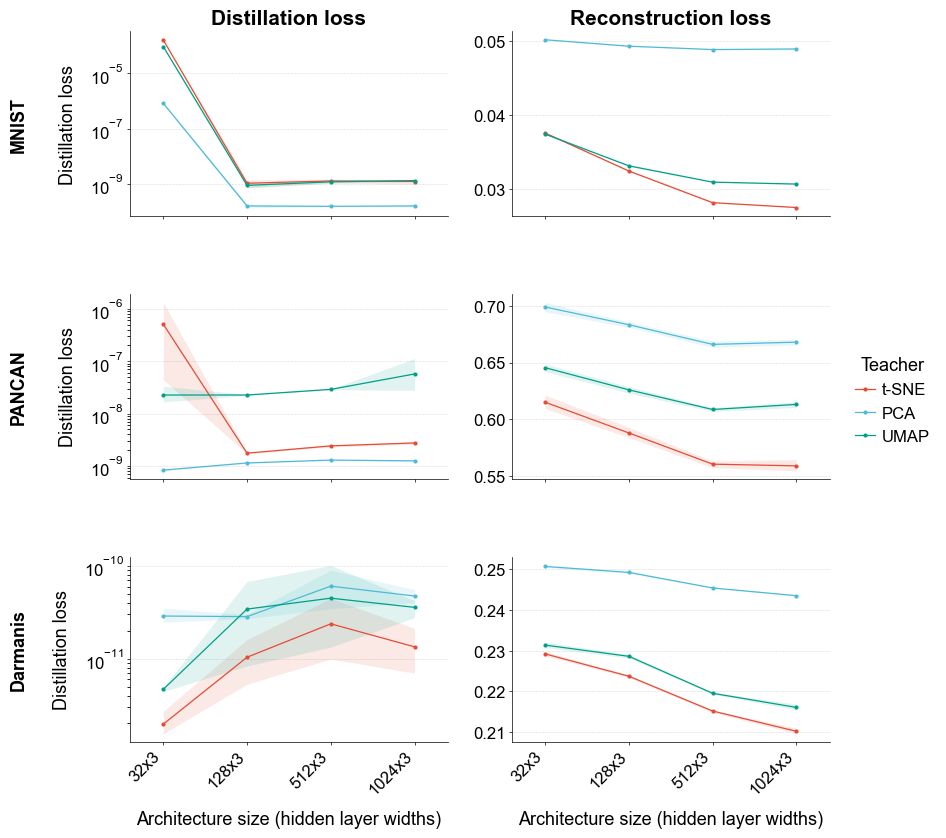

In [24]:
analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'pancan_width_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_pca = pd.read_csv(Path(PATH_PREFIX) / 'gene_cancer_width_analysis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) / 'gene_cancer_width_analysis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_pancan = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis_pancan.fillna('None', inplace=True)

analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'mnist_width_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_pca = pd.read_csv(Path(PATH_PREFIX) / 'mnist_width_analysis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) / 'mnist_width_analysis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_mnist = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis_mnist.fillna('None', inplace=True)

analysis_umap = pd.read_csv(Path(PATH_PREFIX) / 'darmanis_width_analysis_umap.csv')
analysis_umap['teacher'] = "UMAP"
analysis_pca = pd.read_csv(Path(PATH_PREFIX) / 'darmanis_width_analysis_pca.csv')
analysis_pca['teacher'] = "PCA"
analysis_tsne = pd.read_csv(Path(PATH_PREFIX) / 'darmanis_width_analysis_tsne.csv')
analysis_tsne['teacher'] = "TSNE"
analysis_darmanis = pd.concat([analysis_umap, analysis_pca, analysis_tsne], ignore_index=True)
analysis_darmanis.fillna('None', inplace=True)

make_size_figs([(analysis_mnist, "MNIST"),  (analysis_pancan, "PANCAN"), (analysis_darmanis, "Darmanis")], ['32x3', '128x3', '512x3', '1024x3'], set_y_distill_scale=True, figsize_per_row = (10, 3))

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def _sorted_unique(values):
    """Sort numerically when possible, otherwise lexicographically."""
    vals = pd.Series(values).dropna().unique().tolist()

    try:
        return sorted(vals, key=lambda x: float(x))
    except Exception:
        return sorted(vals, key=lambda x: str(x))


def plot_distillation_sweep(
    df: pd.DataFrame,
    dataset_col: str = "dataset",
    teacher_col: str = "teacher",
    hyperparam_col: str = "hyperparameter",
    run_col: str = "seed",
    distill_col: str = "final_distill_loss",
    epochs_col: str = "n_epochs",
    threshold: float = 9e-6,
    jitter: float = 0.12,
    base_point_size: float = 40,
    scale_point_size_by_epochs: bool = False,
    figsize_per_col: float = 4.2,
    figsize_per_row: float = 3.2,
    sharey: bool = True,
    cmap: str = "viridis",
    add_median_line: bool = True,
    annotate_success_rate: bool = False,
):

    needed = [dataset_col, teacher_col, hyperparam_col, distill_col, epochs_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df.copy()

    # Drop rows with missing essentials
    plot_df = plot_df.dropna(subset=needed).copy()

    # Clean up values
    plot_df[distill_col] = pd.to_numeric(plot_df[distill_col], errors="coerce")
    plot_df[epochs_col] = pd.to_numeric(plot_df[epochs_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[distill_col, epochs_col])

    # Avoid log-scale issues
    eps = np.finfo(float).tiny
    plot_df[distill_col] = np.maximum(plot_df[distill_col].values, eps)

    datasets = _sorted_unique(plot_df[dataset_col])
    teachers = _sorted_unique(plot_df[teacher_col])

    n_rows = len(datasets)
    n_cols = len(teachers)

    fig_w = max(4, figsize_per_col * n_cols)
    fig_h = max(3, figsize_per_row * n_rows)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        squeeze=False,
        sharey=sharey
    )

    # Global normalization for epochs so colors are comparable across facets
    epoch_min = plot_df[epochs_col].min()
    epoch_max = plot_df[epochs_col].max()
    if epoch_min == epoch_max:
        epoch_min = epoch_min - 1
        epoch_max = epoch_max + 1
    norm = Normalize(vmin=epoch_min-200, vmax=epoch_max)
    cmap_obj = plt.get_cmap(cmap)

    rng = np.random.default_rng(0)

    for i, ds in enumerate(datasets):
        for j, teacher in enumerate(teachers):
            ax = axes[i, j]
            sub = plot_df[
                (plot_df[dataset_col] == ds) &
                (plot_df[teacher_col] == teacher)
            ].copy()

            if sub.empty:
                ax.set_visible(False)
                continue

            hp_vals = _sorted_unique(sub[hyperparam_col])
            x_map = {hp: idx for idx, hp in enumerate(hp_vals)}



            xs = []
            ys = []
            sizes = []
            facecolors = []
            edgecolors = []
            linewidths = []

            for _, row in sub.iterrows():
                x0 = x_map[row[hyperparam_col]]
                x = x0 
                y = row[distill_col]
                epochs = row[epochs_col]

                if scale_point_size_by_epochs:
                    frac = (epochs - epoch_min) / (epoch_max - epoch_min + 1e-12)
                    size = base_point_size + 100 * frac
                else:
                    size = base_point_size

                color = cmap_obj(norm(epochs))
                failed = y > threshold

                xs.append(x)
                ys.append(y)
                sizes.append(size)
                facecolors.append(color)
                edgecolors.append("red" if failed else "black")
                linewidths.append(1.2 if failed else 0.4)

            ax.scatter(
                xs, ys,
                s=sizes,
                c=facecolors,
                edgecolors=edgecolors,
                linewidths=linewidths,
                alpha=0.9,
                zorder=2
            )

            # Threshold line
            ax.axhline(
                threshold,
                linestyle="--",
                linewidth=1.0,
                alpha=0.9
            )
            ax.set_yscale("log")
            ax.set_xticks(range(len(hp_vals)))
            ax.set_xticklabels([str(v) for v in hp_vals], rotation=45, ha="center", fontsize=15)
            # make ytikcs bigger
            ax.tick_params(axis='y', labelsize=15)

            if i == 0:
                ax.set_title(str(teacher), fontsize=20)
            if j == 0:
                ax.set_ylabel(f"{ds}\n\nFinal distill loss", fontsize=20)
            else:
                ax.set_ylabel("")
            if i == n_rows - 1:
                ax.set_xlabel("Hyperparameter", fontsize=20)
            else:
                ax.set_xlabel("")

    # Shared colorbar for epochs
    sm = ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    cax = fig.add_axes([1, 0.15, 0.02, 0.70])
    cbar = fig.colorbar(sm, cax=cax, shrink=0.92, pad=2)
    cbar.set_label("Training epochs", fontsize=20)

    fig.tight_layout()
    return fig, axes

/var/folders/_t/9_5k5p3j08j7stwypyhjbhr00000gn/T/ipykernel_41990/1195486307.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


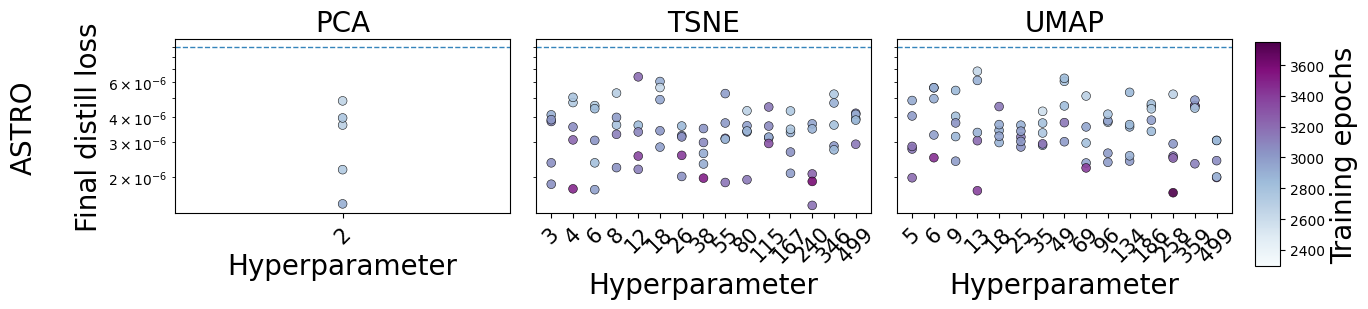

In [134]:
def load_and_combine_sweeps(sweep_configs):
    frames = []
    for cfg in sweep_configs:
        dfi = pd.read_csv(cfg["path"]).copy()
        dfi["dataset"] = cfg["dataset"]
        dfi["teacher"] = cfg["teacher"]

        hp_col = cfg["hyperparameter_col"]
        if hp_col not in dfi.columns:
            raise ValueError(f"Column '{hp_col}' not found in {cfg['path']}")
        dfi["hyperparameter"] = dfi[hp_col]

        frames.append(dfi)

    return pd.concat(frames, ignore_index=True)


sweep_configs = [
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_astro_pca_sweep.csv",
        "dataset": "ASTRO",   
        "teacher": "PCA",
        "hyperparameter_col": "n_components",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_astro_tsne_sweep.csv",
        "dataset": "ASTRO",   
        "teacher": "TSNE",
        "hyperparameter_col": "perplexity",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_astro_umap_sweep.csv",
        "dataset": "ASTRO",  
        "teacher": "UMAP",
        "hyperparameter_col": "n_neighbors",
    },
]

df = load_and_combine_sweeps(sweep_configs)

fig, axes = plot_distillation_sweep(
    df,
    dataset_col="dataset",
    teacher_col="teacher",
    hyperparam_col="hyperparameter",
    run_col="seed",
    distill_col="final_distill_loss",
    epochs_col="n_epochs",
    threshold=9e-6,
    cmap = 'BuPu'
)
plt.show()

/var/folders/_t/9_5k5p3j08j7stwypyhjbhr00000gn/T/ipykernel_41990/1195486307.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


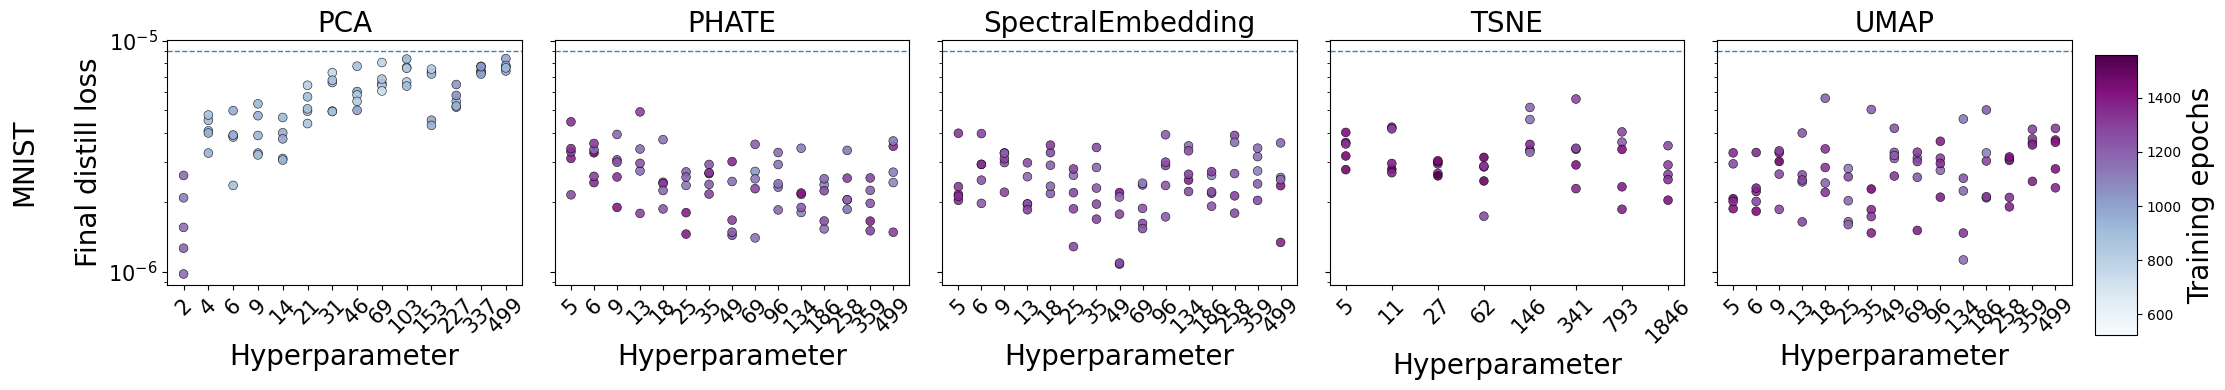

In [135]:
sweep_configs = [
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_mnist_umap_sweep.csv",
        "dataset": "MNIST",   
        "teacher": "UMAP",
        "hyperparameter_col": "n_neighbors",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_mnist_tsne_sweep.csv",
        "dataset": "MNIST",  
        "teacher": "TSNE",
        "hyperparameter_col": "perplexity",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_mnist_pca_sweep.csv",
        "dataset": "MNIST",   
        "teacher": "PCA",
        "hyperparameter_col": "n_components",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_mnist_phate_sweep.csv",
        "dataset": "MNIST",   
        "teacher": "PHATE",
        "hyperparameter_col": "n_neighbors",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_mnist_spectral_sweep.csv",
        "dataset": "MNIST",   
        "teacher": "SpectralEmbedding",
        "hyperparameter_col": "n_neighbors",
    },
]

df = load_and_combine_sweeps(sweep_configs)

fig, axes = plot_distillation_sweep(
    df,
    dataset_col="dataset",
    teacher_col="teacher",
    hyperparam_col="hyperparameter",
    run_col="seed",
    distill_col="final_distill_loss",
    epochs_col="n_epochs",
    threshold=9e-6,
    cmap = 'BuPu',
    figsize_per_row = 4
)

plt.show()

/var/folders/_t/9_5k5p3j08j7stwypyhjbhr00000gn/T/ipykernel_41990/1195486307.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


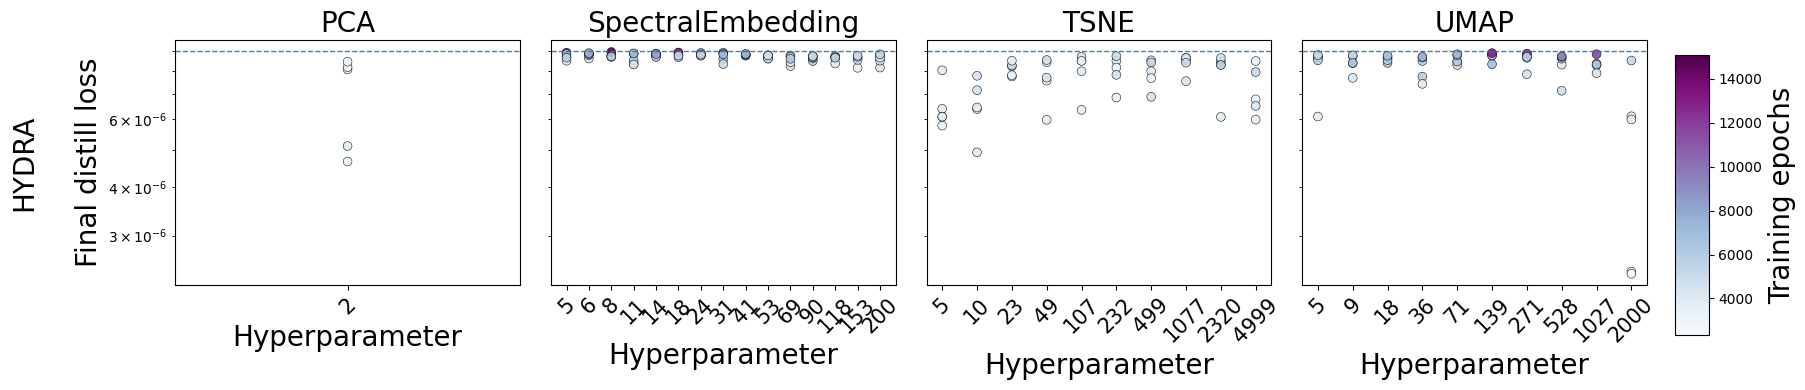

In [136]:
sweep_configs = [
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_hydra_umap_sweep.csv",
        "dataset": "HYDRA",  
        "teacher": "UMAP",
        "hyperparameter_col": "n_neighbors",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_hydra_tsne_sweep.csv",
        "dataset": "HYDRA",  
        "teacher": "TSNE",
        "hyperparameter_col": "perplexity",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_hydra_pca_sweep.csv",
        "dataset": "HYDRA",  
        "teacher": "PCA",
        "hyperparameter_col": "n_components",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_hydra_spectral_sweep.csv",
        "dataset": "HYDRA",  
        "teacher": "SpectralEmbedding",
        "hyperparameter_col": "n_neighbors",
    },
]

df = load_and_combine_sweeps(sweep_configs)

fig, axes = plot_distillation_sweep(
    df,
    dataset_col="dataset",
    teacher_col="teacher",
    hyperparam_col="hyperparameter",
    run_col="seed",
    distill_col="final_distill_loss",
    epochs_col="n_epochs",
    threshold=9e-6,
    cmap = 'BuPu',
    figsize_per_row = 4
)
plt.show()

/var/folders/_t/9_5k5p3j08j7stwypyhjbhr00000gn/T/ipykernel_41990/1195486307.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


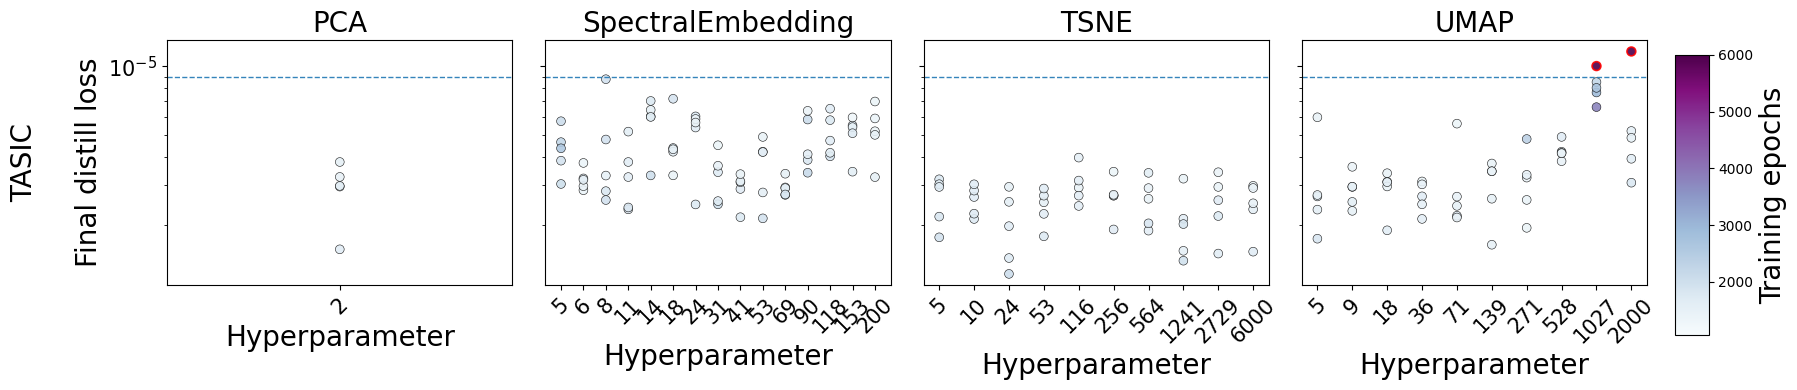

In [137]:
sweep_configs = [
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_tasic_umap_sweep.csv",
        "dataset": "TASIC",  
        "teacher": "UMAP",
        "hyperparameter_col": "n_neighbors",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_tasic_tsne_sweep.csv",
        "dataset": "TASIC",  
        "teacher": "TSNE",
        "hyperparameter_col": "perplexity",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_tasic_pca_sweep.csv",
        "dataset": "TASIC",   
        "teacher": "PCA",
        "hyperparameter_col": "n_components",
    },
    {
        "path": Path(PATH_PREFIX) / "sweep_summary_tasic_spectral_sweep.csv",
        "dataset": "TASIC",   
        "teacher": "SpectralEmbedding",
        "hyperparameter_col": "n_neighbors",
    },
]

df = load_and_combine_sweeps(sweep_configs)

fig, axes = plot_distillation_sweep(
    df,
    dataset_col="dataset",
    teacher_col="teacher",
    hyperparam_col="hyperparameter",
    run_col="seed",
    distill_col="final_distill_loss",
    epochs_col="n_epochs",
    threshold=9e-6,
    cmap = 'BuPu',
    figsize_per_row = 4
)
plt.show()